# Data Job Market Intelligence — Analysis

**Question:** For data roles, *which skills are in demand, what do they pay, and how do roles compare?*

This notebook reads the deduplicated warehouse built by the collection pipeline
(`src/collect.py`) and the skills extracted from posting text (`src/extract_skills.py`),
then walks through the findings. All tables come from `src/analysis.py` and all charts
from `src/figures.py`, so everything here is reproducible — re-run the pipeline and re-run
this notebook.

> **Honesty note:** salary figures use only *genuinely advertised* USD annual salaries.
> Adzuna-predicted salaries are flagged in the data and excluded — otherwise we'd be
> analyzing another model's estimates. Per-skill samples are still small; treat
> everything as directional and watch it firm up as the scheduled collector accumulates data.

In [1]:
%matplotlib inline
import os, sys
# Make the project importable whether this runs from repo root or notebooks/
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src import analysis, figures
from src.storage import load_warehouse, load_skills

jobs = load_warehouse()
skills = load_skills()
print(f'{len(jobs)} postings, {len(skills)} skill mentions')

282 postings, 589 skill mentions


## 1. What's in the dataset

Three public APIs, deliberately complementary: Remotive + Jobicy contribute *real advertised*
salaries (but are remote-only); Adzuna adds volume, geography and on-site roles.

In [2]:
sal = analysis.build_salary_table(jobs)
print('By source        :', jobs['source'].value_counts().to_dict())
print('Remote / on-site :', int(jobs['remote'].sum()), '/', int((~jobs['remote']).sum()))
print('Advertised USD$  :', len(sal), 'postings with a clean annual salary')
jobs[['source', 'title', 'company', 'location', 'salary_min', 'salary_max', 'salary_is_predicted']].head()

By source        : {'adzuna': 150, 'jobicy': 113, 'remotive': 19}
Remote / on-site : 134 / 148
Advertised USD$  : 63 postings with a clean annual salary


,source,title,company,location,salary_min,salary_max,salary_is_predicted
0,adzuna,Data Analyst,Cayuse Holdings,"Washington, D.C., US",109528.08,109528.08,True
1,adzuna,Data Analyst,Cognizant,"Talcott Village, Hartford County",98287.79,98287.79,True
2,adzuna,Data Analyst,Cayuse Holdings,"Annapolis, Anne Arundel County",132172.03,132172.03,True
3,adzuna,Data Analyst,Cognizant,"Ny State Campus, Albany County",102062.77,102062.77,True
4,adzuna,Data Analyst,Cognizant,"Washington, D.C., US",92652.14,92652.14,True


## 2. Which skills are most in demand?

Skills are extracted from description text with a curated taxonomy + a matcher that handles
ambiguous names (`R` vs "R&D", `Java` vs `JavaScript`). Demand = share of postings mentioning a skill.

In [3]:
analysis.demand_table(jobs, skills).head(15)

,skill,postings,pct_of_postings
0,Python,66,23.4
1,SQL,56,19.9
2,Machine Learning,51,18.1
3,AWS,24,8.5
4,Git,20,7.1
5,Statistics,19,6.7
6,Java,17,6.0
7,Tableau,15,5.3
8,GCP,14,5.0
9,Go,13,4.6


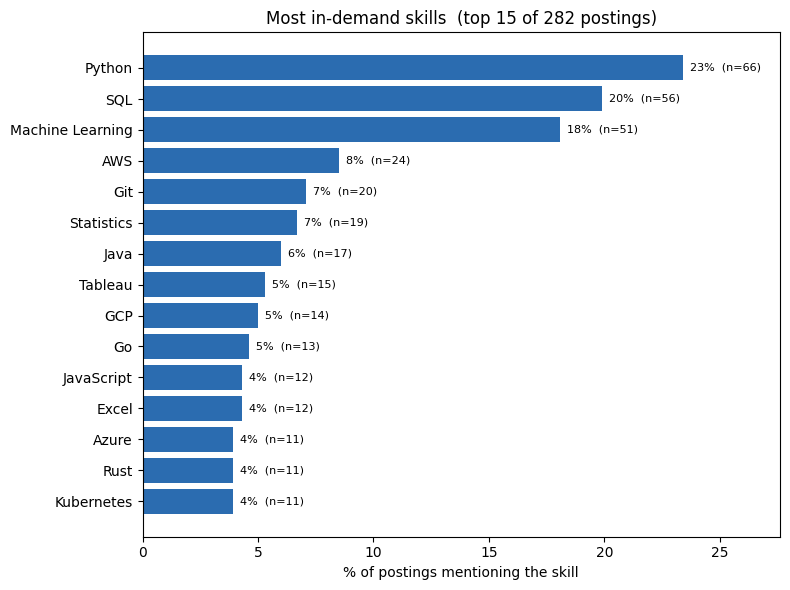

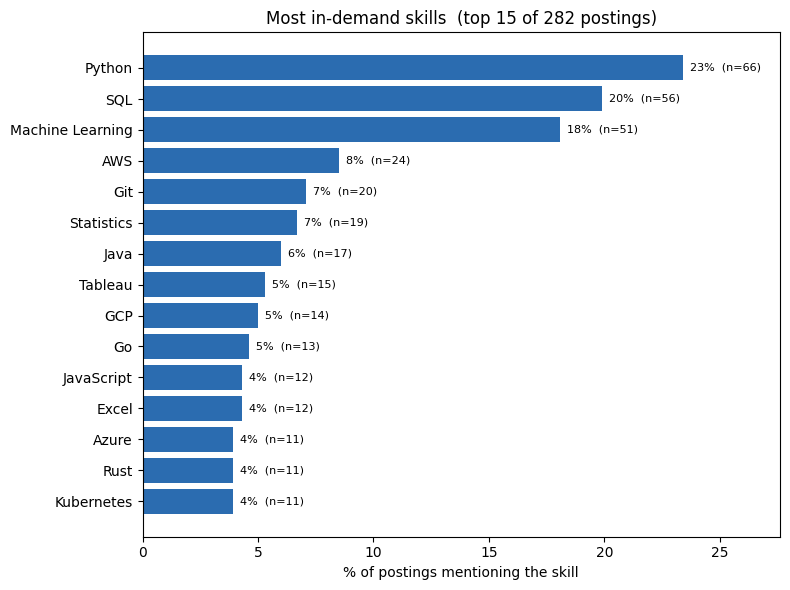

In [4]:
figures.build_demand(jobs, skills)

**Takeaway:** Python, SQL and Machine Learning dominate; everything else trails below ~10%.
SQL's strength is the clearest signal for an aspiring analyst — it shows up nearly everywhere.

## 3. What does each skill pay?

Median advertised salary among postings that mention each skill (USD/yr, advertised only,
skills with at least 5 such postings).

In [5]:
analysis.salary_by_skill(jobs, skills).head(15)

,skill,n,median_salary
0,Hugging Face,5,205000
1,JavaScript,6,182000
2,Deep Learning,5,170200
3,Java,5,165250
4,Databricks,5,157000
5,Machine Learning,13,157000
6,TensorFlow,6,152600
7,PyTorch,7,149500
8,Statistics,11,149500
9,scikit-learn,5,149500


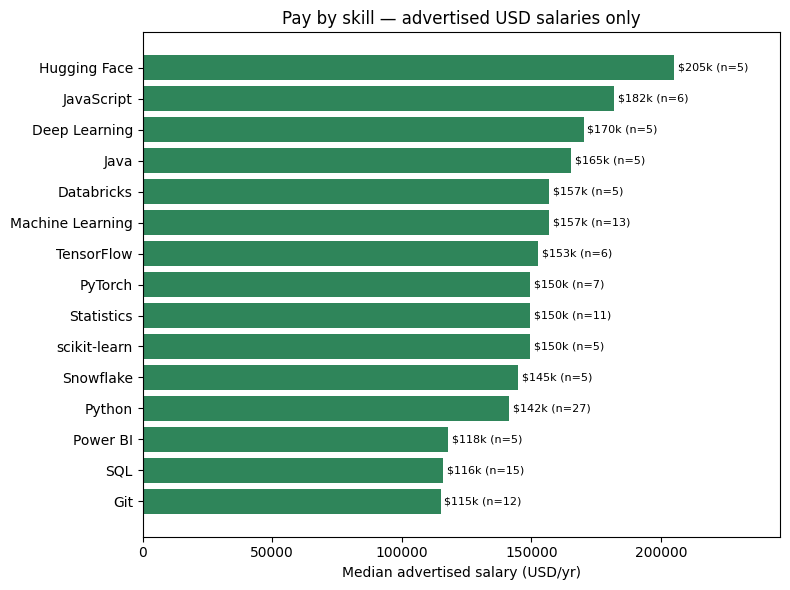

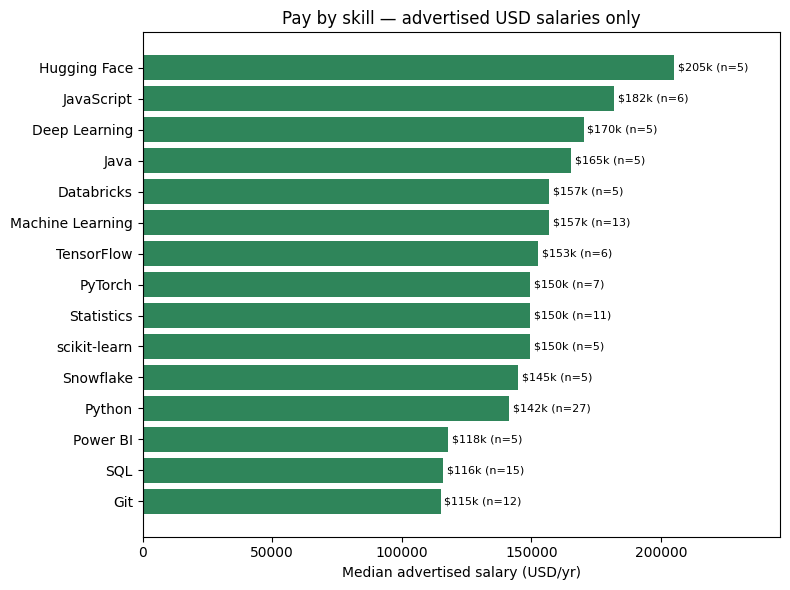

In [6]:
figures.build_salary_by_skill(jobs, skills)

**Takeaway:** specialized ML skills (Deep Learning, PyTorch, TensorFlow) cluster well above
general analytics tooling (dbt, Redshift, Airflow, R). The premium is real, though the small
per-skill samples mean exact dollar figures will move as more data lands.

## 4. How do roles compare?

Posting titles are bucketed into role families (Analyst / Scientist / Engineer / ML) and compared.

In [7]:
analysis.salary_by_role(jobs)

,role,n,median_salary
0,ML Engineer,6,170925
1,Data Scientist,5,140000
2,Other,34,123350
3,Data Analyst,15,120000


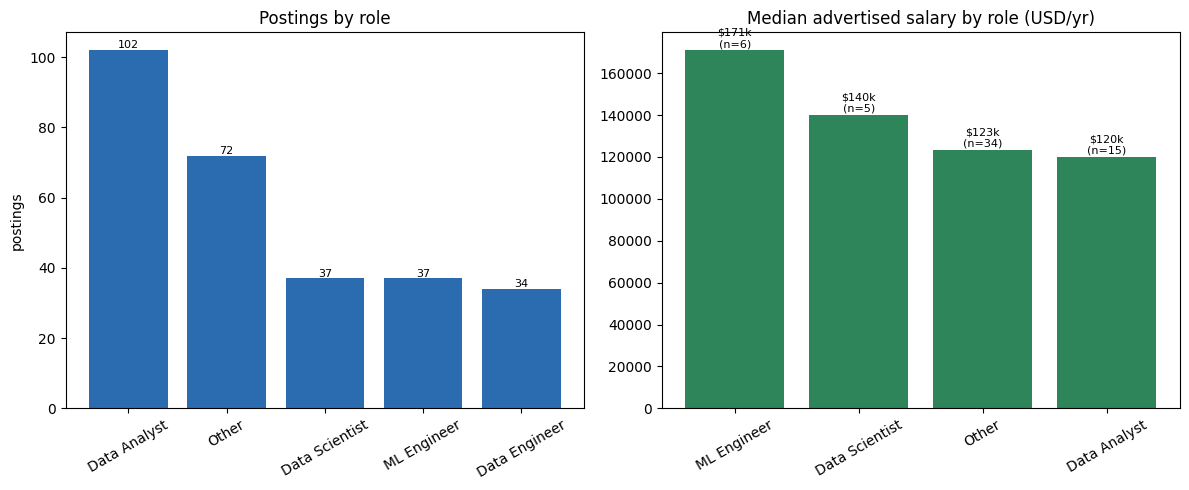

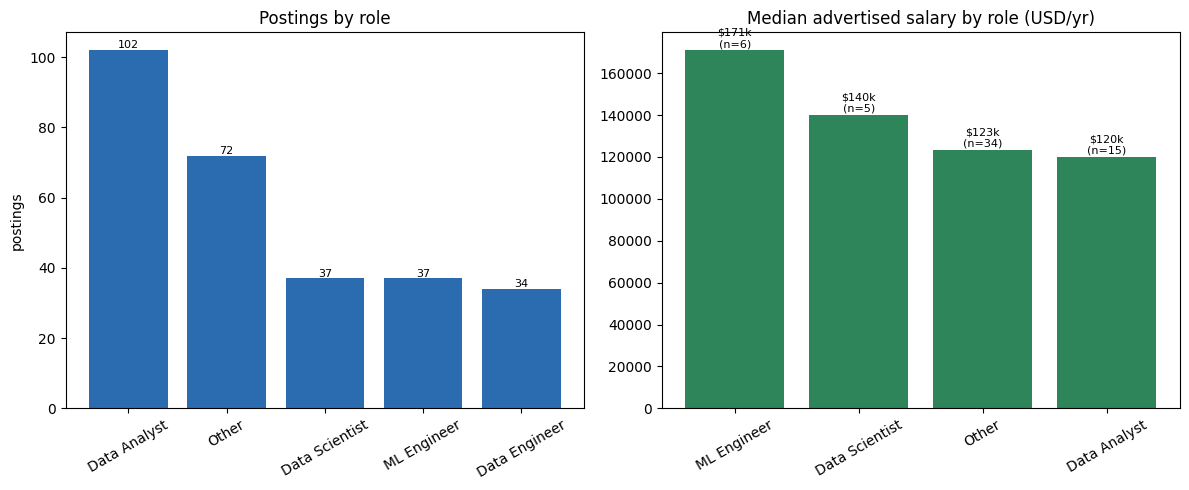

In [8]:
figures.build_roles(jobs)

**Takeaway:** ML Engineer > Data Scientist > Data Analyst on median advertised pay — the
ordering you'd expect, recovered straight from the data.

## 5. Which skills travel together?

Co-occurrence of the most common skills — how often two appear in the same posting.

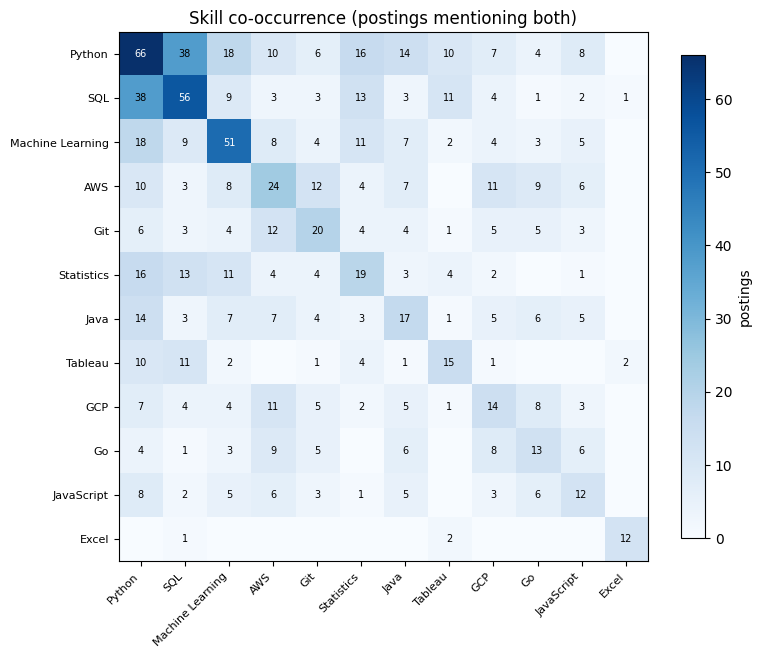

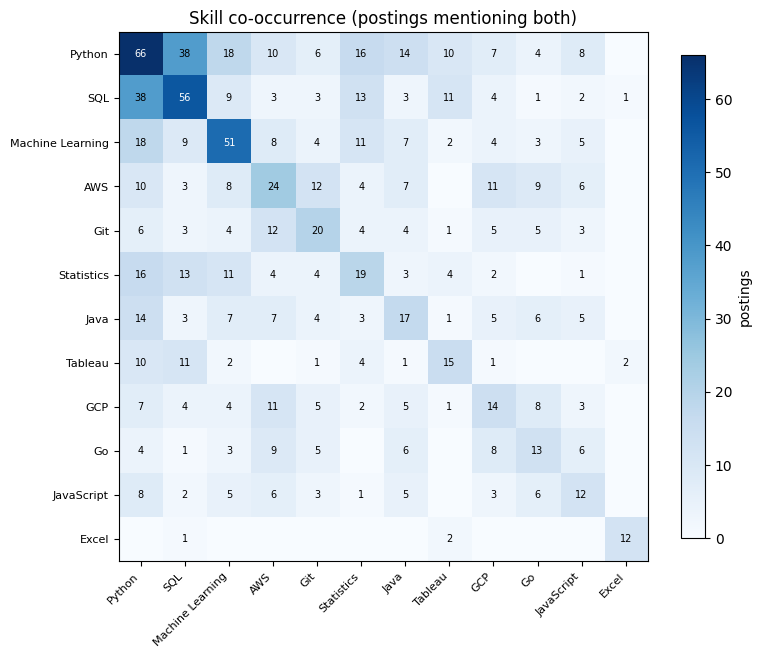

In [9]:
figures.build_cooccurrence(skills)

**Takeaway:** Python+SQL is the backbone pairing of data work, while Excel sits almost on its
own — the signature of a non-programming, analyst-only tool.

---

## Caveats & what's next

- **Sampling bias:** remote-friendly, English-language postings; salary stats cover only the
  USD-advertised subset. Directional, not a census.
- **Dictionary recall:** a skill counts only if it's in the taxonomy, so demand %s are lower bounds.
- **Next (Phase 4):** predict advertised salary from skills/role/location, baseline-first, with
  honest error reporting. **Phase 5:** wrap these views in a deployed Streamlit dashboard.